In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Download dataset
!wget -q https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("========== DATASET OVERVIEW ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
df.info()

print("\n========== MISSING VALUES ==========")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_pct
})

display(missing_table[missing_table["Missing Values"] > 0])

print("\n========== DUPLICATE ROWS ==========")
print("Duplicate rows:", df.duplicated().sum())

print("\n========== UNIQUE VALUES ==========")
display(df.nunique().sort_values().to_frame("Unique Values"))

print("\n========== NUMERICAL SUMMARY ==========")
display(df.describe().T)

print("\n========== CHURN DISTRIBUTION ==========")
display(df["Churn"].value_counts().to_frame("Customers"))

print("\n========== CHURN PERCENTAGE ==========")
churn_pct = df["Churn"].value_counts(normalize=True).mul(100).round(2)
display(churn_pct.to_frame("Percentage"))

========== DATASET OVERVIEW ==========
Rows: 7043
Columns: 21

========== COLUMN NAMES ==========
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

========== DATA TYPES ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleL

,Missing Values,Missing %



========== DUPLICATE ROWS ==========
Duplicate rows: 0

========== UNIQUE VALUES ==========


,Unique Values
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
MultipleLines,3
TechSupport,3
StreamingTV,3



========== NUMERICAL SUMMARY ==========


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75



========== CHURN DISTRIBUTION ==========


,Customers
Churn,
No,5174
Yes,1869



========== CHURN PERCENTAGE ==========


,Percentage
Churn,
No,73.46
Yes,26.54


In [3]:

# Create a copy so the original dataset remains unchanged
df_clean = df.copy()

print("Original shape:", df_clean.shape)

# 1. Remove unnecessary customer ID whitespace
df_clean["customerID"] = df_clean["customerID"].str.strip()

# 2. Convert TotalCharges to numeric
# Invalid/blank values become NaN
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# 3. Check missing values after conversion
print("\nMissing values after conversion:")
display(df_clean.isnull().sum().to_frame("Missing Values"))

# 4. Handle missing TotalCharges
# Use tenure × monthly charges
# for customers with missing TotalCharges
missing_total = df_clean["TotalCharges"].isnull().sum()

df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(
    df_clean["tenure"] * df_clean["MonthlyCharges"]
)

print("\nMissing TotalCharges handled:", missing_total)

# 5. Remove duplicate records
duplicates = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()

print("Duplicate rows removed:", duplicates)

# --------------------------------------------
# 6. Standardize text columns
# --------------------------------------------
text_columns = df_clean.select_dtypes(include="object").columns

for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()

# --------------------------------------------
# 7. Convert Churn into binary target
# No = 0, Yes = 1
# --------------------------------------------
df_clean["Churn_Binary"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

# 8. Final validation
print("\n========== CLEAN DATASET ==========")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nMissing values remaining:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows remaining:")
print(df_clean.duplicated().sum())

print("\nChurn target:")
display(df_clean["Churn_Binary"].value_counts().sort_index())

print("\n========== CLEAN DATA PREVIEW ==========")
display(df_clean.head())

Original shape: (7043, 21)

Missing values after conversion:


,Missing Values
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Missing TotalCharges handled: 11
Duplicate rows removed: 0

========== CLEAN DATASET ==========
Rows: 7043
Columns: 22

Missing values remaining:
0

Duplicate rows remaining:
0

Churn target:


,count
Churn_Binary,
0,5174
1,1869



========== CLEAN DATA PREVIEW ==========


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


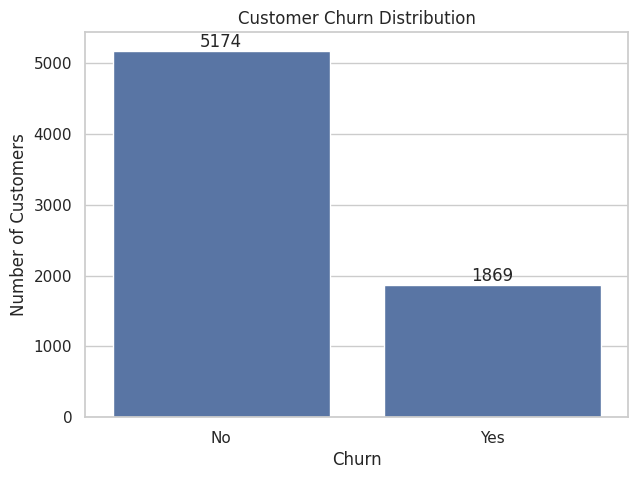

========== OVERALL CHURN ==========
Total Customers : 7,043
Churned         : 1,869
Retained        : 5,174
Churn Rate      : 26.54%

========== CHURN BY CONTRACT ==========


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


<Figure size 900x500 with 0 Axes>

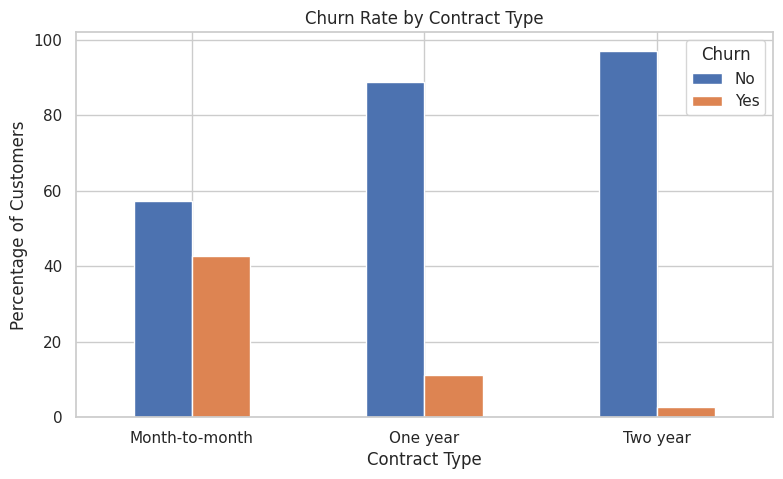


========== CHURN BY INTERNET SERVICE ==========


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


<Figure size 900x500 with 0 Axes>

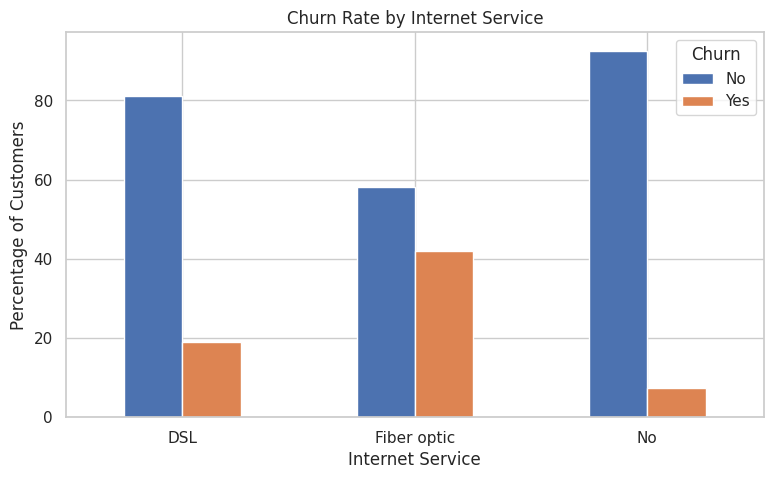


========== CHURN BY PAYMENT METHOD ==========


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


<Figure size 1100x500 with 0 Axes>

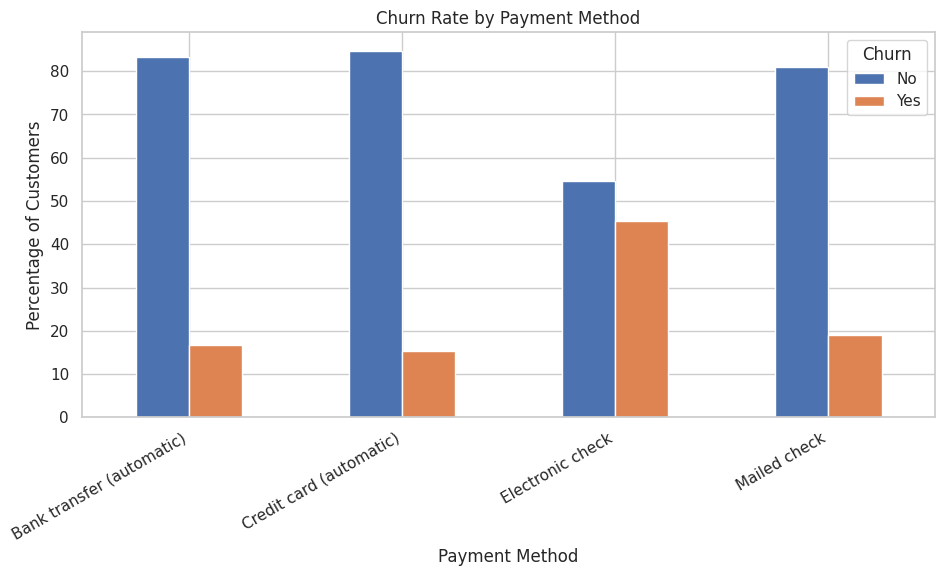


========== CHURN BY TENURE ==========


Churn,No,Yes
TenureGroup,,
0–12 Months,52.56,47.44
13–24 Months,71.29,28.71
25–48 Months,79.61,20.39
49–72 Months,90.49,9.51


<Figure size 900x500 with 0 Axes>

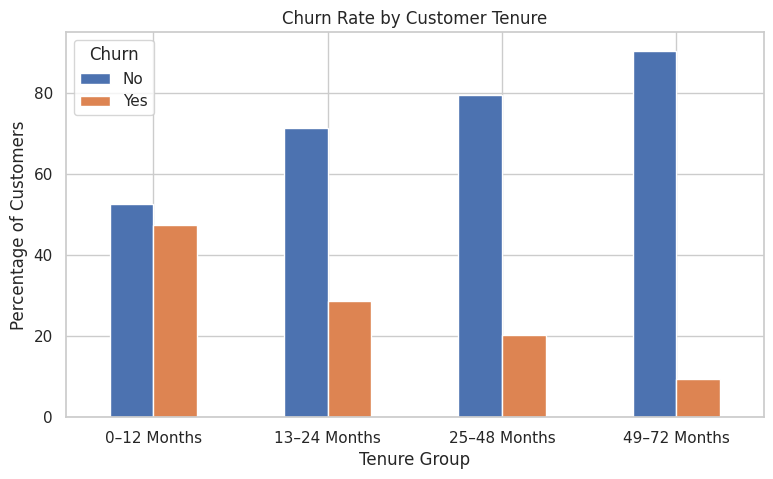

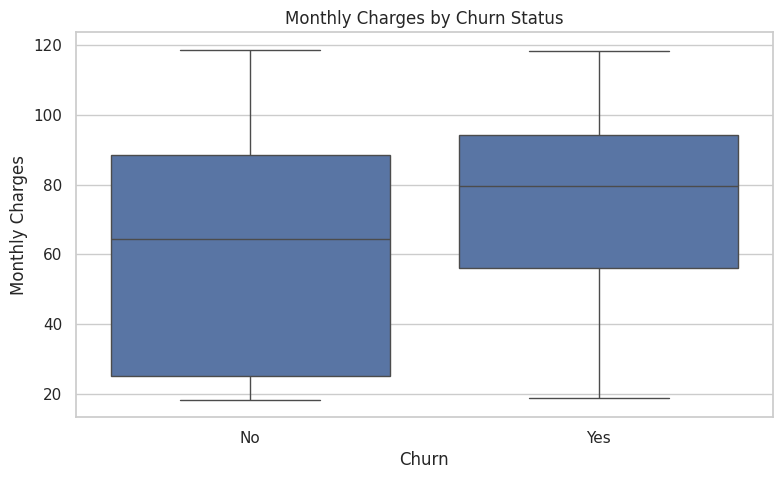

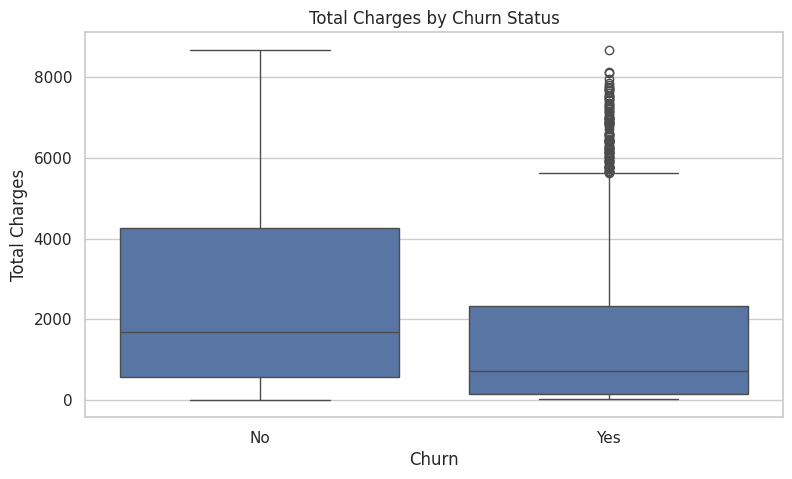


========== CHURN BY SENIOR CITIZEN STATUS ==========


Churn,No,Yes
Non-Senior,76.39,23.61
Senior Citizen,58.32,41.68



========== CHURN BY GENDER ==========


Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


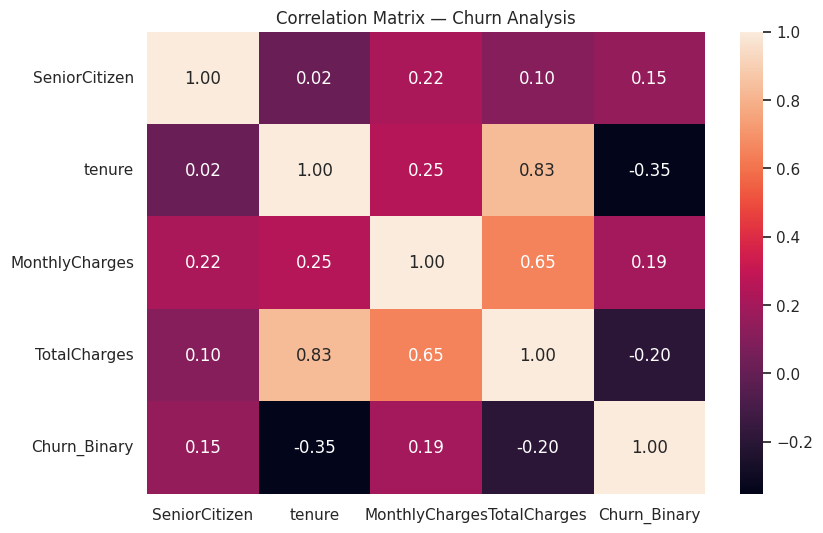


========== EDA COMPLETE ==========


In [4]:

# Set plotting style
sns.set_theme(style="whitegrid")

# --------------------------------------------
# 1. Overall Churn Distribution
# --------------------------------------------
churn_counts = df_clean["Churn"].value_counts()

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

print("========== OVERALL CHURN ==========")
churn_rate = (df_clean["Churn_Binary"].mean() * 100)

print(f"Total Customers : {len(df_clean):,}")
print(f"Churned         : {(df_clean['Churn_Binary'] == 1).sum():,}")
print(f"Retained        : {(df_clean['Churn_Binary'] == 0).sum():,}")
print(f"Churn Rate      : {churn_rate:.2f}%")

# --------------------------------------------
# 2. Churn by Contract Type
# --------------------------------------------
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY CONTRACT ==========")
display(contract_churn.round(2))

plt.figure(figsize=(9, 5))
contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# --------------------------------------------
# 3. Churn by Internet Service
# --------------------------------------------
internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY INTERNET SERVICE ==========")
display(internet_churn.round(2))

plt.figure(figsize=(9, 5))
internet_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# --------------------------------------------
# 4. Churn by Payment Method
# --------------------------------------------
payment_churn = pd.crosstab(
    df_clean["PaymentMethod"],
    df_clean["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY PAYMENT METHOD ==========")
display(payment_churn.round(2))

plt.figure(figsize=(11, 5))
payment_churn.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Churn")
plt.show()

# --------------------------------------------
# 5. Churn by Tenure
# --------------------------------------------
df_clean["TenureGroup"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0–12 Months", "13–24 Months", "25–48 Months", "49–72 Months"]
)

tenure_churn = pd.crosstab(
    df_clean["TenureGroup"],
    df_clean["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY TENURE ==========")
display(tenure_churn.round(2))

plt.figure(figsize=(9, 5))
tenure_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# --------------------------------------------
# 6. Monthly Charges vs Churn
# --------------------------------------------
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

# --------------------------------------------
# 7. Total Charges vs Churn
# --------------------------------------------
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

# --------------------------------------------
# 8. Senior Citizen Churn
# --------------------------------------------
senior_churn = pd.crosstab(
    df_clean["SeniorCitizen"],
    df_clean["Churn"],
    normalize="index"
) * 100

senior_churn.index = ["Non-Senior", "Senior Citizen"]

print("\n========== CHURN BY SENIOR CITIZEN STATUS ==========")
display(senior_churn.round(2))

# --------------------------------------------
# 9. Gender Churn
# --------------------------------------------
gender_churn = pd.crosstab(
    df_clean["gender"],
    df_clean["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY GENDER ==========")
display(gender_churn.round(2))

# --------------------------------------------
# 10. Correlation of Numerical Variables
# --------------------------------------------
numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Binary"
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    df_clean[numeric_cols].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix — Churn Analysis")
plt.show()

print("\n========== EDA COMPLETE ==========")

In [5]:
import sqlite3
import pandas as pd

# Create SQLite database
conn = sqlite3.connect("customer_churn.db")

# Load cleaned data into SQL table
df_clean.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully!")

# --------------------------------------------
# 1. Overall Customer & Churn KPIs
# --------------------------------------------

query1 = """
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    SUM(CASE WHEN Churn = 'No' THEN 1 ELSE 0 END) AS retained_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers;
"""

print("\n========== OVERALL CHURN KPIs ==========")
display(pd.read_sql_query(query1, conn))


# --------------------------------------------
# 2. Churn by Contract
# --------------------------------------------

query2 = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

print("\n========== CHURN BY CONTRACT ==========")
display(pd.read_sql_query(query2, conn))


# --------------------------------------------
# 3. Churn by Internet Service
# --------------------------------------------

query3 = """
SELECT
    InternetService,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

print("\n========== CHURN BY INTERNET SERVICE ==========")
display(pd.read_sql_query(query3, conn))


# --------------------------------------------
# 4. Churn by Payment Method
# --------------------------------------------

query4 = """
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;
"""

print("\n========== CHURN BY PAYMENT METHOD ==========")
display(pd.read_sql_query(query4, conn))


# --------------------------------------------
# 5. Churn by Tenure Group
# --------------------------------------------

query5 = """
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 Months'
        WHEN tenure <= 24 THEN '13-24 Months'
        WHEN tenure <= 48 THEN '25-48 Months'
        ELSE '49-72 Months'
    END AS tenure_group,

    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY tenure_group

ORDER BY
    CASE tenure_group
        WHEN '0-12 Months' THEN 1
        WHEN '13-24 Months' THEN 2
        WHEN '25-48 Months' THEN 3
        WHEN '49-72 Months' THEN 4
    END;
"""

print("\n========== CHURN BY TENURE ==========")
display(pd.read_sql_query(query5, conn))


# --------------------------------------------
# 6. Average Charges by Churn Status
# --------------------------------------------

query6 = """
SELECT
    Churn,
    COUNT(*) AS customers,
    ROUND(AVG(tenure), 2) AS avg_tenure,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(AVG(TotalCharges), 2) AS avg_total_charges
FROM customers
GROUP BY Churn;
"""

print("\n========== CHARGES BY CHURN STATUS ==========")
display(pd.read_sql_query(query6, conn))


# --------------------------------------------
# 7. High-Value Churned Customers
# --------------------------------------------

query7 = """
SELECT
    customerID,
    Contract,
    tenure,
    MonthlyCharges,
    TotalCharges,
    InternetService,
    Churn
FROM customers
WHERE Churn = 'Yes'
ORDER BY TotalCharges DESC
LIMIT 10;
"""

print("\n========== TOP 10 HIGH-VALUE CHURNED CUSTOMERS ==========")
display(pd.read_sql_query(query7, conn))


# --------------------------------------------
# 8. Revenue at Risk
# --------------------------------------------

query8 = """
SELECT
    COUNT(*) AS churned_customers,
    ROUND(SUM(MonthlyCharges), 2) AS monthly_revenue_at_risk,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_revenue_per_churned_customer
FROM customers
WHERE Churn = 'Yes';
"""

print("\n========== REVENUE AT RISK ==========")
display(pd.read_sql_query(query8, conn))


# --------------------------------------------
# 9. Churn by Senior Citizen Status
# --------------------------------------------

query9 = """
SELECT
    SeniorCitizen,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY SeniorCitizen
ORDER BY churn_rate DESC;
"""

print("\n========== CHURN BY SENIOR CITIZEN STATUS ==========")
display(pd.read_sql_query(query9, conn))


# --------------------------------------------
# 10. Close SQL Connection
# --------------------------------------------

conn.close()

print("\n============================================")
print("SQL ANALYSIS COMPLETE")
print("============================================")

SQL database created successfully!

========== OVERALL CHURN KPIs ==========


,total_customers,churned_customers,retained_customers,churn_rate
0,7043,1869,5174,26.54



========== CHURN BY CONTRACT ==========


,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83



========== CHURN BY INTERNET SERVICE ==========


...


========== REVENUE AT RISK ==========


,churned_customers,monthly_revenue_at_risk,avg_monthly_revenue_per_churned_customer
0,1869,139130.85,74.44



========== CHURN BY SENIOR CITIZEN STATUS ==========


,SeniorCitizen,total_customers,churned_customers,churn_rate
0,1,1142,476,41.68
1,0,5901,1393,23.61



SQL ANALYSIS COMPLETE


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# --------------------------------------------
# 1. Create ML dataset
# --------------------------------------------

ml_df = df_clean.copy()

# Remove columns that should NOT be used as predictors
# customerID = identifier
# Churn = original target
# Churn_Binary = encoded target
# TenureGroup = derived from tenure; we'll use the original tenure instead
ml_df = ml_df.drop(
    columns=["customerID", "Churn", "Churn_Binary", "TenureGroup"],
    errors="ignore"
)

# --------------------------------------------
# 2. Define features and target
# --------------------------------------------

X = ml_df.copy()
y = df_clean["Churn_Binary"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# --------------------------------------------
# 3. Identify numerical and categorical columns
# --------------------------------------------

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\n========== NUMERICAL FEATURES ==========")
print(numeric_features)

print("\n========== CATEGORICAL FEATURES ==========")
print(categorical_features)

# --------------------------------------------
# 4. Preprocessing
# --------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# --------------------------------------------
# 5. Train/Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========== TRAIN / TEST SPLIT ==========")
print("Training records:", X_train.shape[0])
print("Testing records :", X_test.shape[0])

print("\nTraining churn rate:",
      round(y_train.mean() * 100, 2), "%")

print("Testing churn rate :",
      round(y_test.mean() * 100, 2), "%")

# --------------------------------------------
# 6. Verify target distribution
# --------------------------------------------

print("\n========== TARGET DISTRIBUTION ==========")

target_distribution = pd.DataFrame({
    "Class": ["Retained", "Churned"],
    "Count": [
        (y == 0).sum(),
        (y == 1).sum()
    ],
    "Percentage": [
        round((y == 0).mean() * 100, 2),
        round((y == 1).mean() * 100, 2)
    ]
})

display(target_distribution)

print("\n========== FEATURE ENGINEERING COMPLETE ==========")

Features shape: (7043, 19)
Target shape: (7043,)

========== NUMERICAL FEATURES ==========
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

========== CATEGORICAL FEATURES ==========
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

========== TRAIN / TEST SPLIT ==========
Training records: 5634
Testing records : 1409

Training churn rate: 26.54 %
Testing churn rate : 26.54 %

========== TARGET DISTRIBUTION ==========


,Class,Count,Percentage
0,Retained,5174,73.46
1,Churned,1869,26.54



========== FEATURE ENGINEERING COMPLETE ==========


========== MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.70,66.04,56.15,60.69,84.22
1,Random Forest,79.91,65.12,52.41,58.07,83.99



========== LOGISTIC REGRESSION ==========
              precision    recall  f1-score   support

    Retained       0.85      0.90      0.87      1035
     Churned       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


========== RANDOM FOREST ==========
              precision    recall  f1-score   support

    Retained       0.84      0.90      0.87      1035
     Churned       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



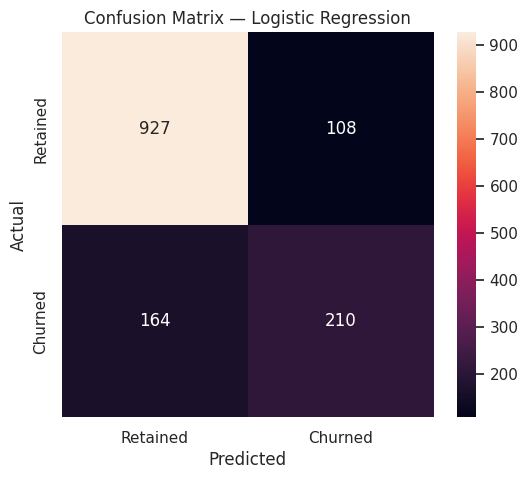

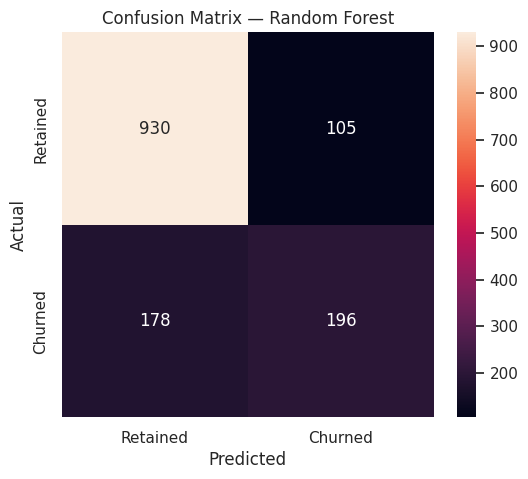

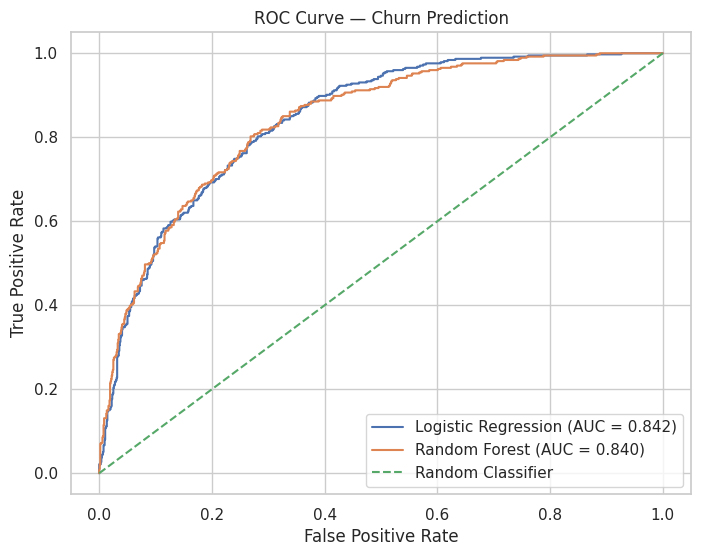


MODEL TRAINING & EVALUATION COMPLETE


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================
# 1. Logistic Regression
# ============================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

# Predictions
lr_pred = logistic_model.predict(X_test)
lr_prob = logistic_model.predict_proba(X_test)[:, 1]


# ============================================
# 2. Random Forest
# ============================================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]


# ============================================
# 3. Evaluation Function
# ============================================

def evaluate_model(name, y_true, predictions, probabilities):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1-Score": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }


# ============================================
# 4. Model Comparison
# ============================================

results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred,
        lr_prob
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
])

# Format metrics
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results[metric_columns] = (
    results[metric_columns] * 100
).round(2)

print("========== MODEL COMPARISON ==========")
display(results)


# ============================================
# 5. Logistic Regression Report
# ============================================

print("\n========== LOGISTIC REGRESSION ==========")
print(
    classification_report(
        y_test,
        lr_pred,
        target_names=["Retained", "Churned"]
    )
)


# ============================================
# 6. Random Forest Report
# ============================================

print("\n========== RANDOM FOREST ==========")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Retained", "Churned"]
    )
)


# ============================================
# 7. Confusion Matrix — Logistic Regression
# ============================================

cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"]
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================
# 8. Confusion Matrix — Random Forest
# ============================================

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"]
)

plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================
# 9. ROC Curve
# ============================================

from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve — Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


print("\n============================================")
print("MODEL TRAINING & EVALUATION COMPLETE")
print("============================================")

========== TOP 15 CHURN PREDICTORS ==========


,Feature,Importance
0,tenure,0.1815
1,TotalCharges,0.1727
2,MonthlyCharges,0.1341
3,InternetService_Fiber optic,0.0597
4,PaymentMethod_Electronic check,0.0522
5,Contract_Two year,0.0511
6,OnlineSecurity_Yes,0.0331
7,Contract_One year,0.0303
8,TechSupport_Yes,0.0239
9,PaperlessBilling_Yes,0.0232


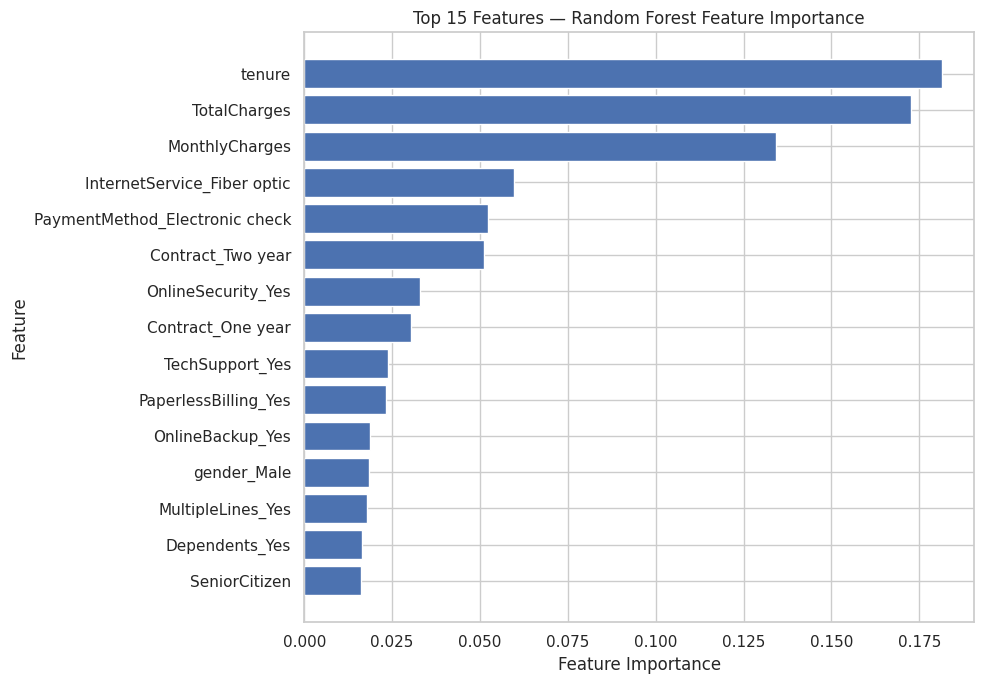


========== STRONGEST LOGISTIC REGRESSION FEATURES ==========


,Feature,Coefficient,Absolute_Coefficient
0,Contract_Two year,-1.3264,1.3264
1,tenure,-1.2505,1.2505
2,InternetService_Fiber optic,1.1823,1.1823
3,Contract_One year,-0.6866,0.6866
4,TotalCharges,0.5231,0.5231
5,PhoneService_Yes,-0.5051,0.5051
6,MonthlyCharges,-0.4708,0.4708
7,PaymentMethod_Electronic check,0.3839,0.3839
8,StreamingTV_Yes,0.3775,0.3775
9,StreamingMovies_Yes,0.3761,0.3761



========== FEATURE IMPORTANCE SUMMARY ==========


,Feature,Importance
0,tenure,0.181479
1,TotalCharges,0.172726
2,MonthlyCharges,0.134107
3,InternetService_Fiber optic,0.059727
4,PaymentMethod_Electronic check,0.052155
5,Contract_Two year,0.051054
6,OnlineSecurity_Yes,0.033075
7,Contract_One year,0.030339
8,TechSupport_Yes,0.023861
9,PaperlessBilling_Yes,0.023241



FEATURE IMPORTANCE ANALYSIS COMPLETE


In [8]:
# Get the fitted preprocessing pipeline
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

# --------------------------------------------
# 1. Get feature names after preprocessing
# --------------------------------------------

feature_names = rf_preprocessor.get_feature_names_out()

# Clean feature names for readability
feature_names = [
    name.replace("num__", "")
         .replace("cat__", "")
         .replace("onehot__", "")
    for name in feature_names
]

# --------------------------------------------
# 2. Extract Random Forest importance
# --------------------------------------------

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# --------------------------------------------
# 3. Display Top 15 Features
# --------------------------------------------

print("========== TOP 15 CHURN PREDICTORS ==========")

display(
    importance_df.head(15).style.format({
        "Importance": "{:.4f}"
    })
)

# --------------------------------------------
# 4. Visualize Top 15 Features
# --------------------------------------------

top_features = importance_df.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features — Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ============================================
# 5. Logistic Regression Coefficients
# ============================================

lr_preprocessor = logistic_model.named_steps["preprocessor"]
lr_classifier = logistic_model.named_steps["classifier"]

lr_feature_names = lr_preprocessor.get_feature_names_out()

lr_feature_names = [
    name.replace("num__", "")
         .replace("cat__", "")
         .replace("onehot__", "")
    for name in lr_feature_names
]

coefficient_df = pd.DataFrame({
    "Feature": lr_feature_names,
    "Coefficient": lr_classifier.coef_[0]
})

# Absolute coefficient strength
coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print("\n========== STRONGEST LOGISTIC REGRESSION FEATURES ==========")

display(
    coefficient_df.head(15).style.format({
        "Coefficient": "{:.4f}",
        "Absolute_Coefficient": "{:.4f}"
    })
)


# ============================================
# 6. Create model interpretation table
# ============================================

top_rf = importance_df.head(15).copy()

print("\n========== FEATURE IMPORTANCE SUMMARY ==========")

display(top_rf)


print("\n============================================")
print("FEATURE IMPORTANCE ANALYSIS COMPLETE")
print("============================================")

========== CUSTOMER RISK DISTRIBUTION ==========


,Customers,Percentage
Risk_Level,,
High Risk,624,8.86
Medium Risk,1504,21.35
Low Risk,4915,69.79


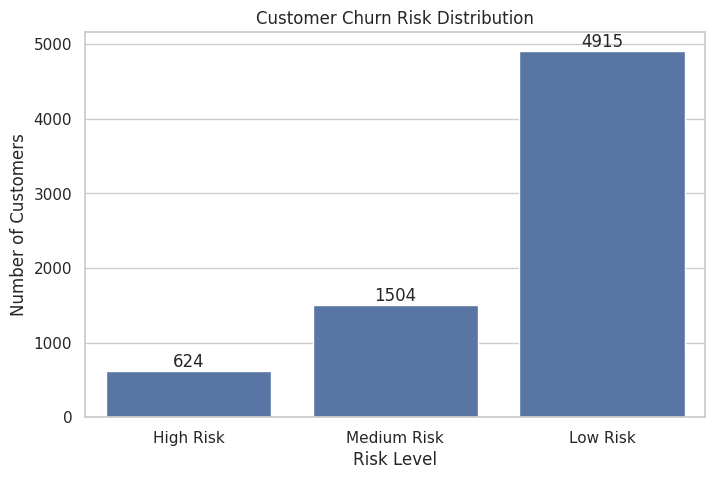


========== REVENUE AT RISK BY CUSTOMER SEGMENT ==========


,Customers,Monthly_Revenue,Average_Monthly_Charges,Average_Tenure,Revenue_Percentage
Risk_Level,,,,,
High Risk,624,50653.85,81.18,4.64,11.11
Medium Risk,1504,111123.75,73.89,18.71,24.36
Low Risk,4915,294339.00,59.89,40.07,64.53



========== TOP 20 HIGH-RISK CUSTOMERS ==========


,customerID,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Risk_Level
1976,9497-QCMMS,1,Month-to-month,Fiber optic,Electronic check,$93.55,$93.55,95.10%,High Risk
4800,9300-AGZNL,1,Month-to-month,Fiber optic,Electronic check,$94.00,$94.00,95.10%,High Risk
4585,1069-XAIEM,1,Month-to-month,Fiber optic,Electronic check,$85.05,$85.05,93.99%,High Risk
2821,4102-OQUPX,1,Month-to-month,Fiber optic,Electronic check,$74.40,$74.40,93.29%,High Risk
6482,5419-JPRRN,1,Month-to-month,Fiber optic,Electronic check,$101.45,$101.45,93.13%,High Risk
3352,9124-LHCJQ,1,Month-to-month,Fiber optic,Mailed check,$85.45,$85.45,92.93%,High Risk
7032,6894-LFHLY,1,Month-to-month,Fiber optic,Electronic check,$75.75,$75.75,92.53%,High Risk
6623,9248-OJYKK,1,Month-to-month,Fiber optic,Electronic check,$76.45,$76.45,92.53%,High Risk
2208,7216-EWTRS,1,Month-to-month,Fiber optic,Electronic check,$100.80,$100.80,92.15%,High Risk
5872,4550-EVXNY,1,Month-to-month,Fiber optic,Electronic check,$69.65,$69.65,92.03%,High Risk



========== HIGH-RISK CUSTOMER METRICS ==========
High-risk customers       : 624
Monthly charges at risk   : $50,653.85
Average monthly charges  : $81.18
Average tenure            : 4.64 months

Files created:
1. customer_churn_risk_analysis.csv
2. high_risk_customers.csv

CUSTOMER RISK SEGMENTATION COMPLETE


In [9]:
# --------------------------------------------
# 1. Generate churn probabilities
# --------------------------------------------

all_probabilities = rf_model.predict_proba(X)[:, 1]

risk_df = df_clean.copy()

risk_df["Churn_Probability"] = all_probabilities

# --------------------------------------------
# 2. Create risk segments
# --------------------------------------------

def assign_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["Risk_Level"] = risk_df["Churn_Probability"].apply(
    assign_risk
)

# --------------------------------------------
# 3. Risk distribution
# --------------------------------------------

risk_summary = (
    risk_df["Risk_Level"]
    .value_counts()
    .reindex(["High Risk", "Medium Risk", "Low Risk"])
    .fillna(0)
    .astype(int)
    .to_frame("Customers")
)

risk_summary["Percentage"] = (
    risk_summary["Customers"]
    / len(risk_df)
    * 100
).round(2)

print("========== CUSTOMER RISK DISTRIBUTION ==========")
display(risk_summary)

# --------------------------------------------
# 4. Visualize risk distribution
# --------------------------------------------

plt.figure(figsize=(8, 5))

risk_counts = risk_summary["Customers"]

ax = sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# --------------------------------------------
# 5. Revenue at Risk by Segment
# --------------------------------------------

revenue_risk = (
    risk_df.groupby("Risk_Level")
    .agg(
        Customers=("customerID", "count"),
        Monthly_Revenue=("MonthlyCharges", "sum"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Tenure=("tenure", "mean")
    )
    .reindex(["High Risk", "Medium Risk", "Low Risk"])
)

revenue_risk["Revenue_Percentage"] = (
    revenue_risk["Monthly_Revenue"]
    / revenue_risk["Monthly_Revenue"].sum()
    * 100
).round(2)

revenue_risk = revenue_risk.round(2)

print("\n========== REVENUE AT RISK BY CUSTOMER SEGMENT ==========")
display(revenue_risk)

# --------------------------------------------
# 6. Top 20 High-Risk Customers
# --------------------------------------------

high_risk_customers = (
    risk_df[risk_df["Risk_Level"] == "High Risk"]
    .sort_values("Churn_Probability", ascending=False)
    [[
        "customerID",
        "tenure",
        "Contract",
        "InternetService",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges",
        "Churn_Probability",
        "Risk_Level"
    ]]
    .head(20)
)

print("\n========== TOP 20 HIGH-RISK CUSTOMERS ==========")

display(
    high_risk_customers.style.format({
        "MonthlyCharges": "${:,.2f}",
        "TotalCharges": "${:,.2f}",
        "Churn_Probability": "{:.2%}"
    })
)

# --------------------------------------------
# 7. High-Risk Customer Summary
# --------------------------------------------

high_risk = risk_df[
    risk_df["Risk_Level"] == "High Risk"
]

print("\n========== HIGH-RISK CUSTOMER METRICS ==========")

print(
    f"High-risk customers       : {len(high_risk):,}"
)

print(
    f"Monthly charges at risk   : "
    f"${high_risk['MonthlyCharges'].sum():,.2f}"
)

print(
    f"Average monthly charges  : "
    f"${high_risk['MonthlyCharges'].mean():,.2f}"
)

print(
    f"Average tenure            : "
    f"{high_risk['tenure'].mean():.2f} months"
)

# --------------------------------------------
# 8. Save risk analysis
# --------------------------------------------

risk_df.to_csv(
    "customer_churn_risk_analysis.csv",
    index=False
)

high_risk_customers.to_csv(
    "high_risk_customers.csv",
    index=False
)

print("\nFiles created:")
print("1. customer_churn_risk_analysis.csv")
print("2. high_risk_customers.csv")

print("\n============================================")
print("CUSTOMER RISK SEGMENTATION COMPLETE")
print("============================================")

In [11]:
# --------------------------------------------
# 1. High-Risk Customers by Contract
# --------------------------------------------

high_risk_contract = (
    high_risk.groupby("Contract")
    .agg(
        High_Risk_Customers=("customerID", "count"),
        Monthly_Revenue_at_Risk=("MonthlyCharges", "sum"),
        Avg_Monthly_Charges=("MonthlyCharges", "mean")
    )
    .sort_values("High_Risk_Customers", ascending=False)
)

print("========== HIGH-RISK CUSTOMERS BY CONTRACT ==========")
display(high_risk_contract.round(2))


# --------------------------------------------
# 2. High-Risk Customers by Internet Service
# --------------------------------------------

high_risk_internet = (
    high_risk.groupby("InternetService")
    .agg(
        High_Risk_Customers=("customerID", "count"),
        Monthly_Revenue_at_Risk=("MonthlyCharges", "sum")
    )
    .sort_values("High_Risk_Customers", ascending=False)
)

print("\n========== HIGH-RISK CUSTOMERS BY INTERNET SERVICE ==========")
display(high_risk_internet.round(2))


# --------------------------------------------
# 3. High-Risk Customers by Payment Method
# --------------------------------------------

high_risk_payment = (
    high_risk.groupby("PaymentMethod")
    .agg(
        High_Risk_Customers=("customerID", "count"),
        Monthly_Revenue_at_Risk=("MonthlyCharges", "sum")
    )
    .sort_values("High_Risk_Customers", ascending=False)
)

print("\n========== HIGH-RISK CUSTOMERS BY PAYMENT METHOD ==========")
display(high_risk_payment.round(2))


# --------------------------------------------
# 4. High-Risk Customers by Tenure
# --------------------------------------------

high_risk["Risk_Tenure_Group"] = pd.cut(
    high_risk["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0–12 Months",
        "13–24 Months",
        "25–48 Months",
        "49–72 Months"
    ]
)

high_risk_tenure = (
    high_risk.groupby(
        "Risk_Tenure_Group",
        observed=False
    )
    .agg(
        High_Risk_Customers=("customerID", "count"),
        Monthly_Revenue_at_Risk=("MonthlyCharges", "sum"),
        Avg_Monthly_Charges=("MonthlyCharges", "mean")
    )
)

print("\n========== HIGH-RISK CUSTOMERS BY TENURE ==========")
display(high_risk_tenure.round(2))


# --------------------------------------------
# 5. Service Adoption Among High-Risk Customers
# --------------------------------------------

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

service_summary = []

for column in service_columns:

    counts = high_risk[column].value_counts()

    for value, count in counts.items():

        service_summary.append({
            "Service": column,
            "Option": value,
            "High_Risk_Customers": count,
            "Percentage": count / len(high_risk) * 100
        })

service_summary = pd.DataFrame(service_summary)

print("\n========== SERVICE DISTRIBUTION AMONG HIGH-RISK CUSTOMERS ==========")

display(
    service_summary.sort_values(
        "High_Risk_Customers",
        ascending=False
    ).round(2)
)


# --------------------------------------------
# 6. Compare High-Risk vs Overall Customers
# --------------------------------------------

comparison = pd.DataFrame({
    "Metric": [
        "Customers",
        "Average Tenure",
        "Average Monthly Charges",
        "Average Total Charges"
    ],

    "Overall Customers": [
        len(df_clean),
        df_clean["tenure"].mean(),
        df_clean["MonthlyCharges"].mean(),
        df_clean["TotalCharges"].mean()
    ],

    "High-Risk Customers": [
        len(high_risk),
        high_risk["tenure"].mean(),
        high_risk["MonthlyCharges"].mean(),
        high_risk["TotalCharges"].mean()
    ]
})

comparison.iloc[1:, 1:] = comparison.iloc[1:, 1:].round(2)

print("\n========== OVERALL VS HIGH-RISK CUSTOMERS ==========")
display(comparison)


# --------------------------------------------
# 7. Business Insight Summary
# --------------------------------------------

print("\n============================================")
print("BUSINESS INSIGHT SUMMARY")
print("============================================")

print(
    f"""
1. Total customers analyzed:
   {len(df_clean):,}

2. Customers classified as high risk:
   {len(high_risk):,}

3. Monthly charges associated with high-risk customers:
   ${high_risk['MonthlyCharges'].sum():,.2f}

4. Average tenure of high-risk customers:
   {high_risk['tenure'].mean():.2f} months

5. Average monthly charges of high-risk customers:
   ${high_risk['MonthlyCharges'].mean():,.2f}
"""
)


# --------------------------------------------
# 8. Export Business Analysis
# --------------------------------------------

with pd.ExcelWriter(
    "Customer_Churn_Business_Analysis.xlsx",
    engine="openpyxl"
) as writer:

    risk_summary.to_excel(
        writer,
        sheet_name="Risk Summary"
    )

    revenue_risk.to_excel(
        writer,
        sheet_name="Revenue at Risk"
    )

    high_risk_contract.to_excel(
        writer,
        sheet_name="Contract Risk"
    )

    high_risk_internet.to_excel(
        writer,
        sheet_name="Internet Risk"
    )

    high_risk_payment.to_excel(
        writer,
        sheet_name="Payment Risk"
    )

    high_risk_tenure.to_excel(
        writer,
        sheet_name="Tenure Risk"
    )

    comparison.to_excel(
        writer,
        sheet_name="Overall vs High Risk",
        index=False
    )

print("\nExcel business analysis created:")
print("Customer_Churn_Business_Analysis.xlsx")

========== HIGH-RISK CUSTOMERS BY CONTRACT ==========


,High_Risk_Customers,Monthly_Revenue_at_Risk,Avg_Monthly_Charges
Contract,,,
Month-to-month,624,50653.85,81.18



========== HIGH-RISK CUSTOMERS BY INTERNET SERVICE ==========


,High_Risk_Customers,Monthly_Revenue_at_Risk
InternetService,,
Fiber optic,575,48866.55
DSL,46,1726.90
No,3,60.40



========== HIGH-RISK CUSTOMERS BY PAYMENT METHOD ==========


...


========== SERVICE DISTRIBUTION AMONG HIGH-RISK CUSTOMERS ==========


,Service,Option,High_Risk_Customers,Percentage
0,PhoneService,Yes,586,93.91
5,OnlineSecurity,No,584,93.59
14,TechSupport,No,572,91.67
8,OnlineBackup,No,507,81.25
11,DeviceProtection,No,477,76.44
20,StreamingMovies,No,338,54.17
17,StreamingTV,No,325,52.08
2,MultipleLines,Yes,307,49.20
18,StreamingTV,Yes,296,47.44
21,StreamingMovies,Yes,283,45.35



========== OVERALL VS HIGH-RISK CUSTOMERS ==========


,Metric,Overall Customers,High-Risk Customers
0,Customers,7043.00,624.00
1,Average Tenure,32.37,4.64
2,Average Monthly Charges,64.76,81.18
3,Average Total Charges,2279.73,414.10



BUSINESS INSIGHT SUMMARY

1. Total customers analyzed:
   7,043

2. Customers classified as high risk:
   624

3. Monthly charges associated with high-risk customers:
   $50,653.85

4. Average tenure of high-risk customers:
   4.64 months

5. Average monthly charges of high-risk customers:
   $81.18


Excel business analysis created:
Customer_Churn_Business_Analysis.xlsx


In [12]:
sql_script = r"""
-- ============================================================
-- CUSTOMER CHURN ANALYSIS
-- Project 2 — Customer Churn Prediction & Retention Analytics
-- Database: SQLite
-- ============================================================


-- ============================================================
-- 1. OVERALL CUSTOMER & CHURN KPIs
-- ============================================================

SELECT
    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,

    SUM(
        CASE WHEN Churn = 'No' THEN 1 ELSE 0 END
    ) AS retained_customers,

    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers;


-- ============================================================
-- 2. CHURN BY CONTRACT
-- ============================================================

SELECT
    Contract,
    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY Contract

ORDER BY churn_rate DESC;


-- ============================================================
-- 3. CHURN BY INTERNET SERVICE
-- ============================================================

SELECT
    InternetService,
    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY InternetService

ORDER BY churn_rate DESC;


-- ============================================================
-- 4. CHURN BY PAYMENT METHOD
-- ============================================================

SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY PaymentMethod

ORDER BY churn_rate DESC;


-- ============================================================
-- 5. CHURN BY TENURE GROUP
-- ============================================================

SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 Months'
        WHEN tenure <= 24 THEN '13-24 Months'
        WHEN tenure <= 48 THEN '25-48 Months'
        ELSE '49-72 Months'
    END AS tenure_group,

    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY tenure_group

ORDER BY
    CASE tenure_group
        WHEN '0-12 Months' THEN 1
        WHEN '13-24 Months' THEN 2
        WHEN '25-48 Months' THEN 3
        WHEN '49-72 Months' THEN 4
    END;


-- ============================================================
-- 6. AVERAGE CUSTOMER VALUE BY CHURN STATUS
-- ============================================================

SELECT
    Churn,
    COUNT(*) AS customers,
    ROUND(AVG(tenure), 2) AS avg_tenure,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(AVG(TotalCharges), 2) AS avg_total_charges

FROM customers

GROUP BY Churn;


-- ============================================================
-- 7. HIGH-VALUE CHURNED CUSTOMERS
-- ============================================================

SELECT
    customerID,
    Contract,
    tenure,
    InternetService,
    PaymentMethod,
    MonthlyCharges,
    TotalCharges,
    Churn

FROM customers

WHERE Churn = 'Yes'

ORDER BY TotalCharges DESC

LIMIT 10;


-- ============================================================
-- 8. MONTHLY REVENUE AT RISK
-- ============================================================

SELECT
    COUNT(*) AS churned_customers,

    ROUND(
        SUM(MonthlyCharges),
        2
    ) AS monthly_revenue_at_risk,

    ROUND(
        AVG(MonthlyCharges),
        2
    ) AS avg_monthly_revenue_per_churned_customer

FROM customers

WHERE Churn = 'Yes';


-- ============================================================
-- 9. CHURN BY SENIOR CITIZEN STATUS
-- ============================================================

SELECT
    SeniorCitizen,
    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY SeniorCitizen

ORDER BY churn_rate DESC;


-- ============================================================
-- 10. CHURN BY GENDER
-- ============================================================

SELECT
    gender,
    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY gender

ORDER BY churn_rate DESC;


-- ============================================================
-- 11. HIGH-CHARGE CUSTOMERS WHO CHURNED
-- ============================================================

SELECT
    customerID,
    tenure,
    Contract,
    InternetService,
    MonthlyCharges,
    TotalCharges,
    Churn

FROM customers

WHERE Churn = 'Yes'
  AND MonthlyCharges >= (
      SELECT AVG(MonthlyCharges)
      FROM customers
  )

ORDER BY MonthlyCharges DESC;


-- ============================================================
-- 12. CUSTOMERS WITH HIGH MONTHLY CHARGES
--     AND SHORT TENURE
-- ============================================================

SELECT
    customerID,
    tenure,
    Contract,
    MonthlyCharges,
    TotalCharges,
    Churn

FROM customers

WHERE tenure <= 12
  AND MonthlyCharges >= (
      SELECT AVG(MonthlyCharges)
      FROM customers
  )

ORDER BY MonthlyCharges DESC;


-- ============================================================
-- END OF CUSTOMER CHURN SQL ANALYSIS
-- ============================================================
"""

with open("customer_churn_analysis.sql", "w", encoding="utf-8") as f:
    f.write(sql_script)

print("SQL file created successfully!")
print("File: customer_churn_analysis.sql")

# Verify
with open("customer_churn_analysis.sql", "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Total SQL lines:", len(lines))

SQL file created successfully!
File: customer_churn_analysis.sql
Total SQL lines: 313
